In [1]:
import torch
import torchvision
from torchvision.transforms import v2

In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                        shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.12.1+cpu
False
None
No GPU


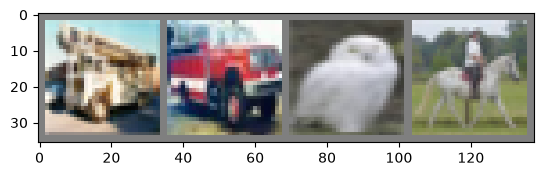

truck truck bird  horse


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [4]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding= 1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding= 1)
        self.conv3 = nn.Conv2d(32,64,3,  padding= 1)
        self.conv4 = nn.Conv2d(64,64,3,  padding= 1)
        self.conv5 = nn.Conv2d(64,128,3,  padding= 1)
        self.conv6 = nn.Conv2d(128,128,3,  padding= 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    # Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => Conv(3x3) => Conv(3x3) => Pool(2x2) => 
    def forward(self, x):
        # 3 x 32 x 32 (Initial)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x) 
        # 32 x 16 x 16 (Block 1 ) 
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        # 64 x 8 x 8 ( Block 2)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)
        # 128 x 4 x 4 (Block 3)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [9]:
for epoch in range(15):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 1.593
[1,  4000] loss: 1.538
[1,  6000] loss: 1.474
[1,  8000] loss: 1.374
[1, 10000] loss: 1.310
[1, 12000] loss: 1.256
[2,  2000] loss: 1.166
[2,  4000] loss: 1.107
[2,  6000] loss: 1.071
[2,  8000] loss: 1.014
[2, 10000] loss: 1.000
[2, 12000] loss: 0.943
[3,  2000] loss: 0.870
[3,  4000] loss: 0.847
[3,  6000] loss: 0.834
[3,  8000] loss: 0.836
[3, 10000] loss: 0.786
[3, 12000] loss: 0.766
[4,  2000] loss: 0.683
[4,  4000] loss: 0.679
[4,  6000] loss: 0.694
[4,  8000] loss: 0.683
[4, 10000] loss: 0.696
[4, 12000] loss: 0.674
[5,  2000] loss: 0.546
[5,  4000] loss: 0.570
[5,  6000] loss: 0.604
[5,  8000] loss: 0.578
[5, 10000] loss: 0.591
[5, 12000] loss: 0.602
[6,  2000] loss: 0.479
[6,  4000] loss: 0.495
[6,  6000] loss: 0.501
[6,  8000] loss: 0.519
[6, 10000] loss: 0.501
[6, 12000] loss: 0.503
[7,  2000] loss: 0.379
[7,  4000] loss: 0.403
[7,  6000] loss: 0.434
[7,  8000] loss: 0.453
[7, 10000] loss: 0.451
[7, 12000] loss: 0.462
[8,  2000] loss: 0.325
[8,  4000] 

In [10]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 75 %


In [11]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 76.3 %
Accuracy for class: car   is 88.4 %
Accuracy for class: bird  is 64.0 %
Accuracy for class: cat   is 69.0 %
Accuracy for class: deer  is 63.3 %
Accuracy for class: dog   is 64.0 %
Accuracy for class: frog  is 77.2 %
Accuracy for class: horse is 74.8 %
Accuracy for class: ship  is 90.0 %
Accuracy for class: truck is 88.6 %
